In [1]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from PIL import Image

%matplotlib inline

In [2]:
def julia_1(c):
    
    z = np.random.uniform(-1, 1) + 1.j * np.random.uniform(-1, 1)
    max_iter = 100    
    Z = np.array((z))
    for i in range(1,max_iter):
#         print(z)
        if Z.size > 1:
            z = Z[i-1]**2 + c
        else:
            z = z**2 + c
        if np.abs(z) > 2:
            break
        Z = np.append(Z, z)
        
    return Z

In [15]:
def julia_2(c):
    max_iter = 100
    n = 400
    iters = np.zeros((n,n))
    k_n = 0
    
    for k in np.linspace(-2,2,n-1):
        p_n = 0
        for p in np.linspace(-2,2,n-1):
            Z = k + p*1.j
            it = 0
       
            for i in range(1,max_iter):
                Z = Z**2 + c
#                 print(k_n, p_n)
                iters[k_n, p_n] = i
                
                if np.abs(Z) > 2:
                    break   
            p_n += 1
            
        k_n += 1
    return iters

play around with values of C, see the change of evolution

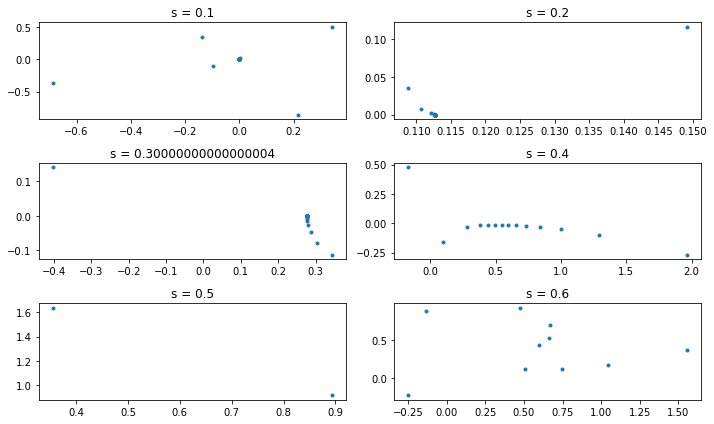

In [63]:
fig, axs = plt.subplots(3,2,  figsize=(10, 6))
s = 0
for ax in axs.flat:
    Z = julia_1(s)
#     print(Z)
    ax.plot(np.real(Z),np.imag(Z),  '.')
    s += 0.1
    ax.set_title('s = ' + str(s))
plt.tight_layout()

In [7]:
c = -0.512511498387847167 + 0.521295573094847167j
iters = julia_2(c)

Different colors for bifurcation points (you can also create your own coloring logic or look for proposals on the internet)

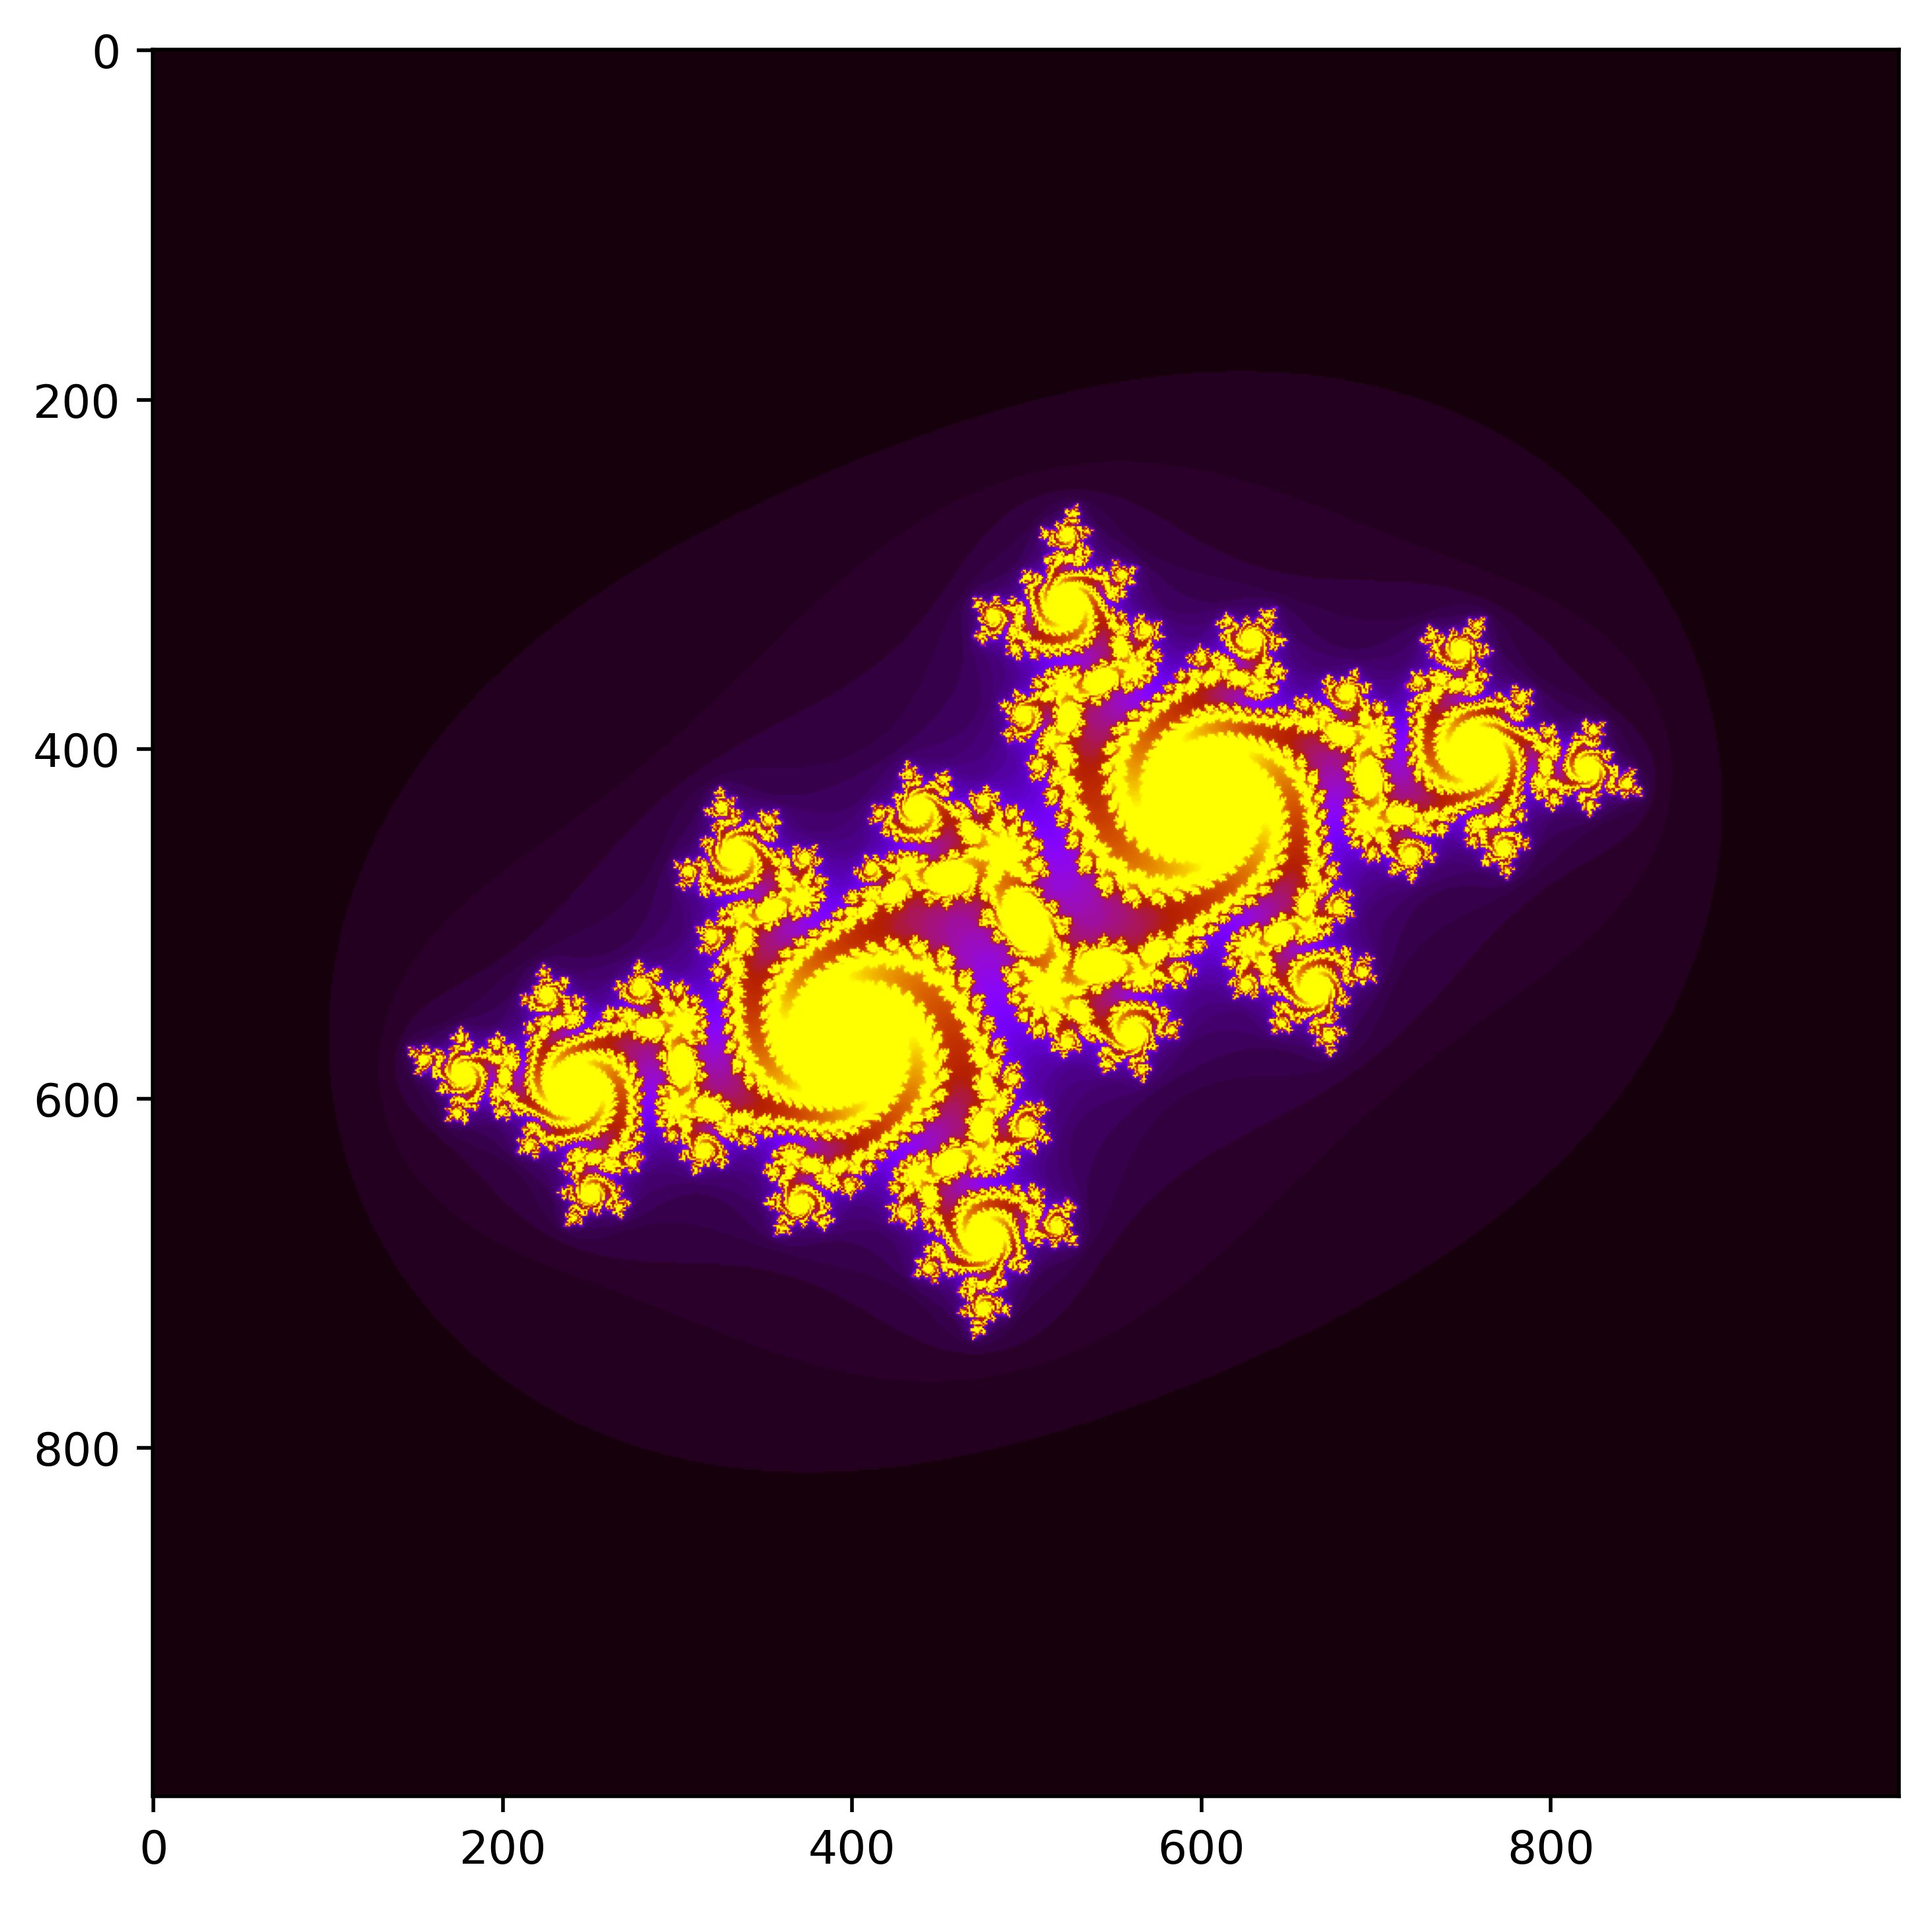

In [8]:
plt.figure(figsize = (7,7), dpi = 500)
plt.imshow(iters.transpose(), cmap='gnuplot')

Black and white colors of pixels are correct (1 point)

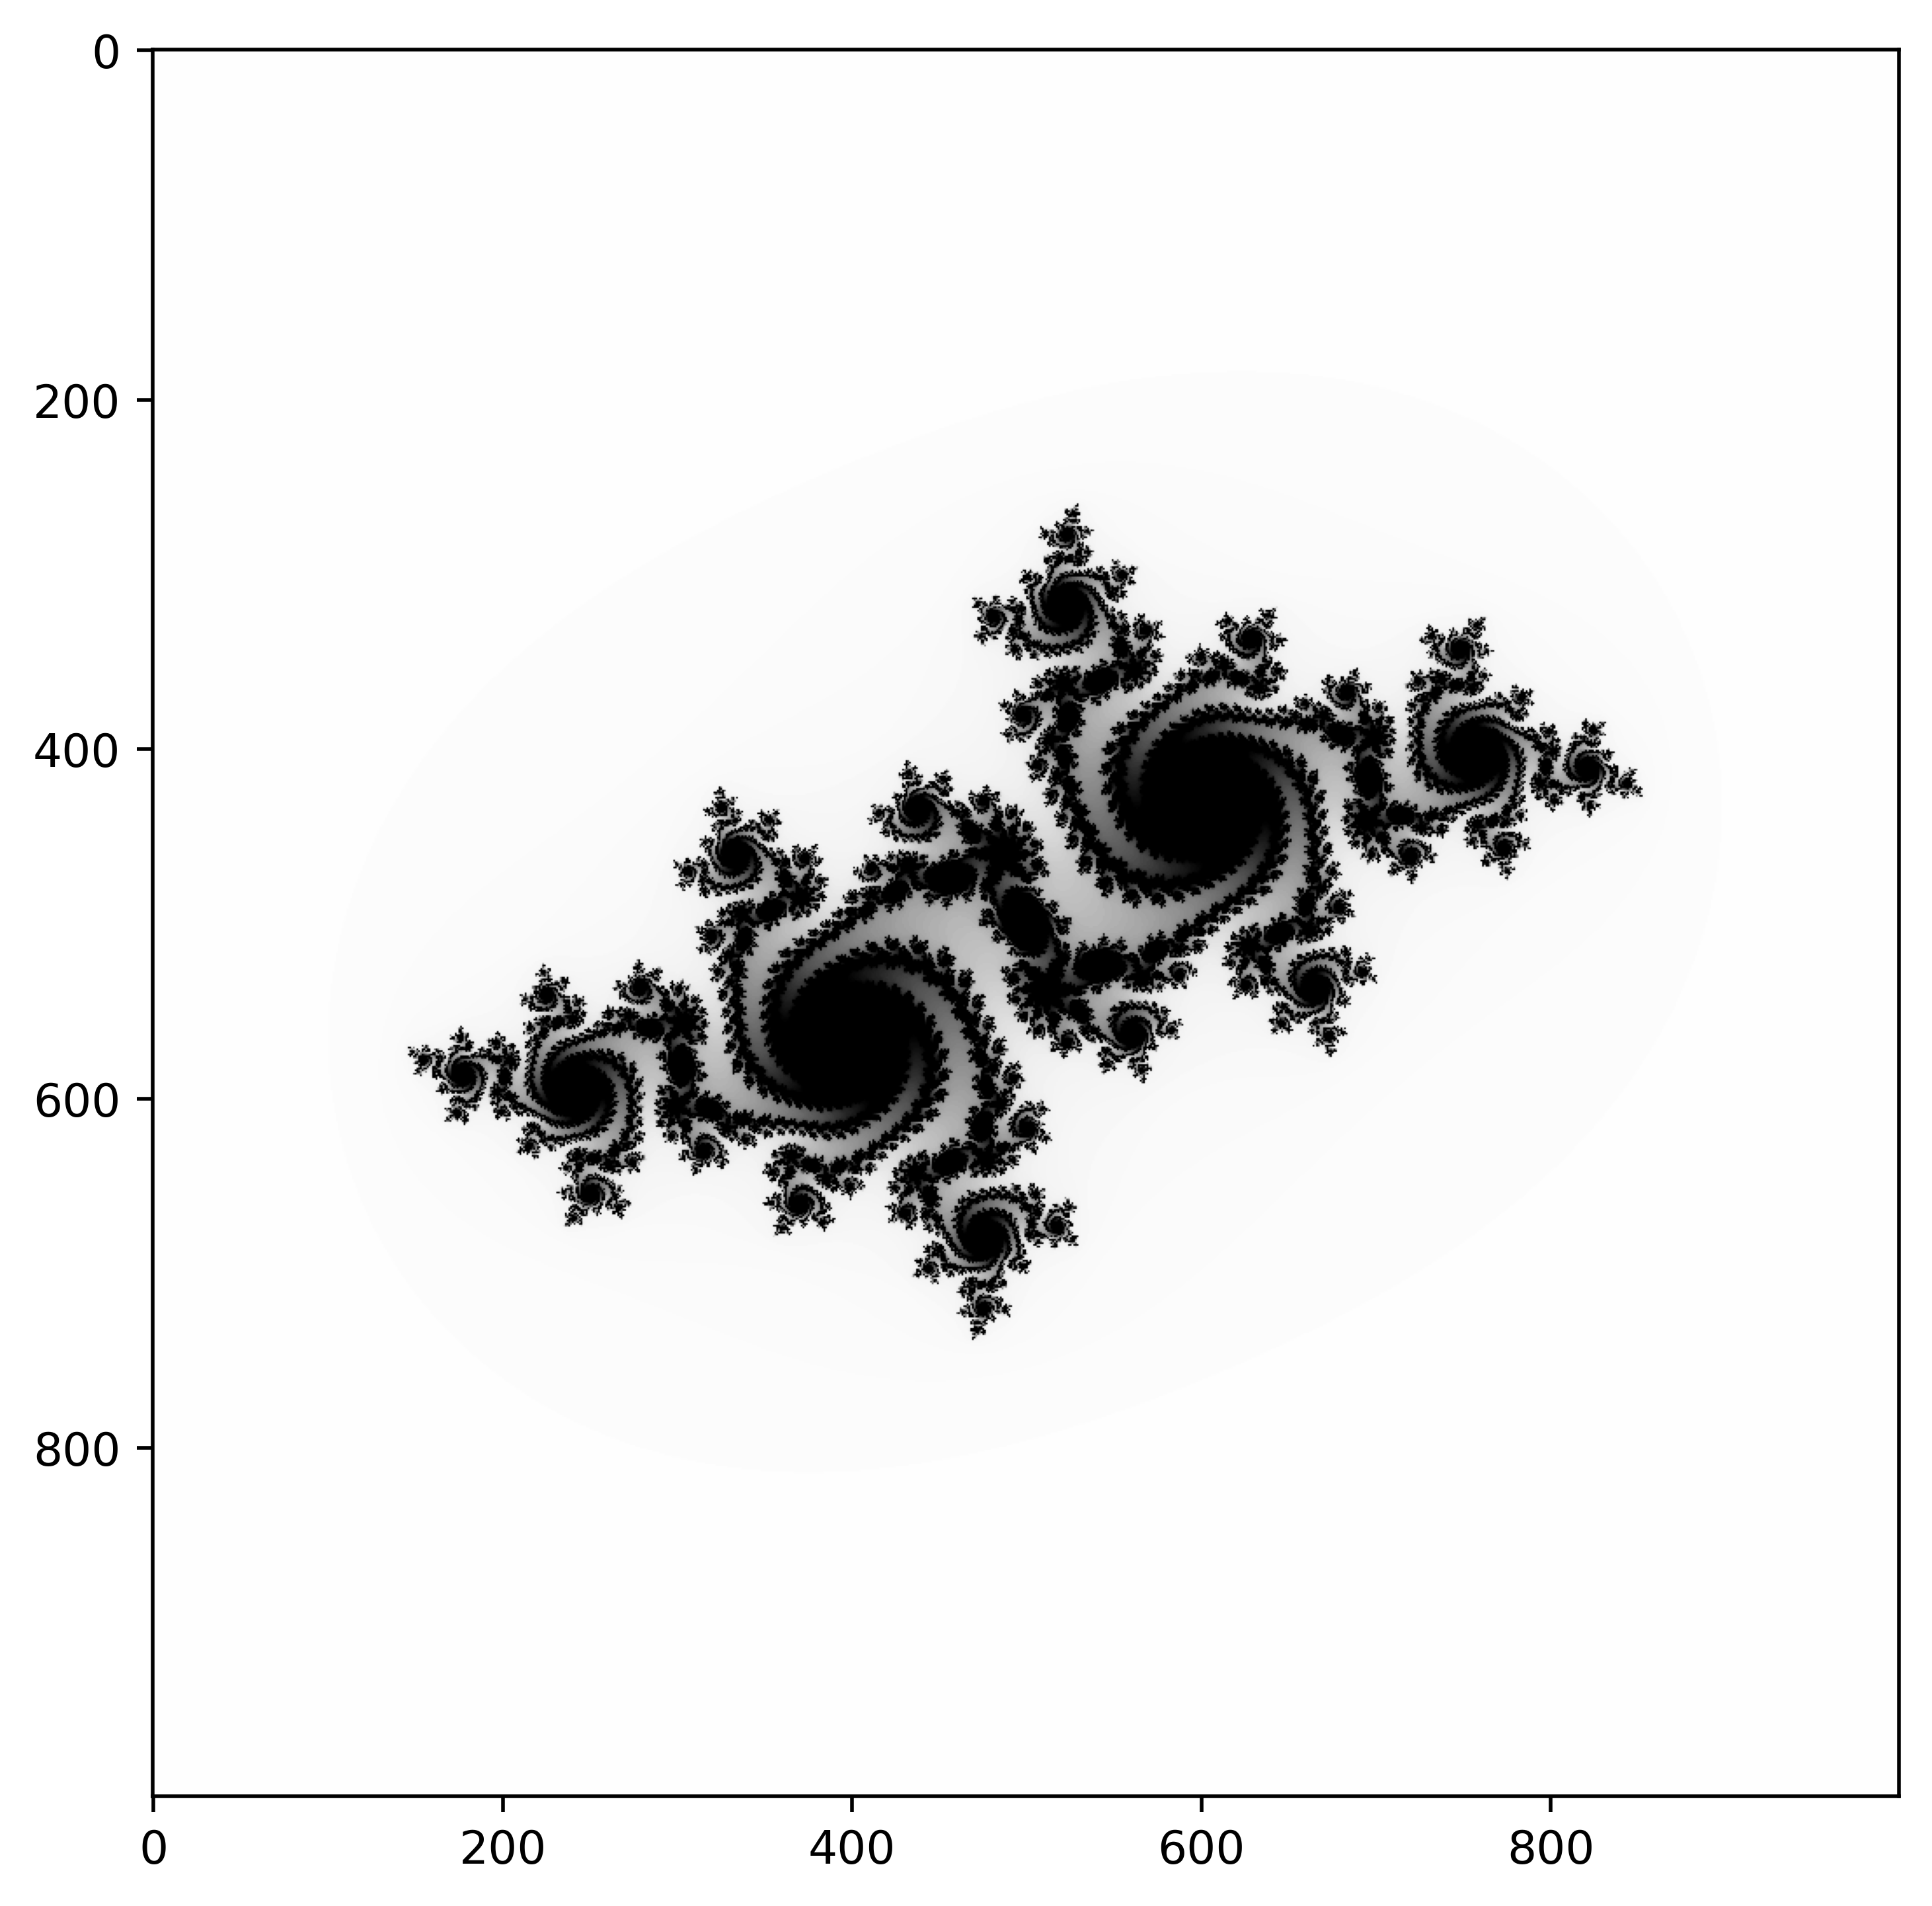

In [11]:
plt.figure(figsize = (7,7), dpi = 500)
plt.imshow(iters.transpose(), cmap='Greys')

Generate figure of Julia set (c = 1-r) where r is the golden ratio. Label the axes (Re(z0), Im(z0)) 

In [12]:
r = (1 + np.sqrt(5))/2
c = 1-r
iters = julia_2(c)

Text(0, 0.5, 'Im(z)')

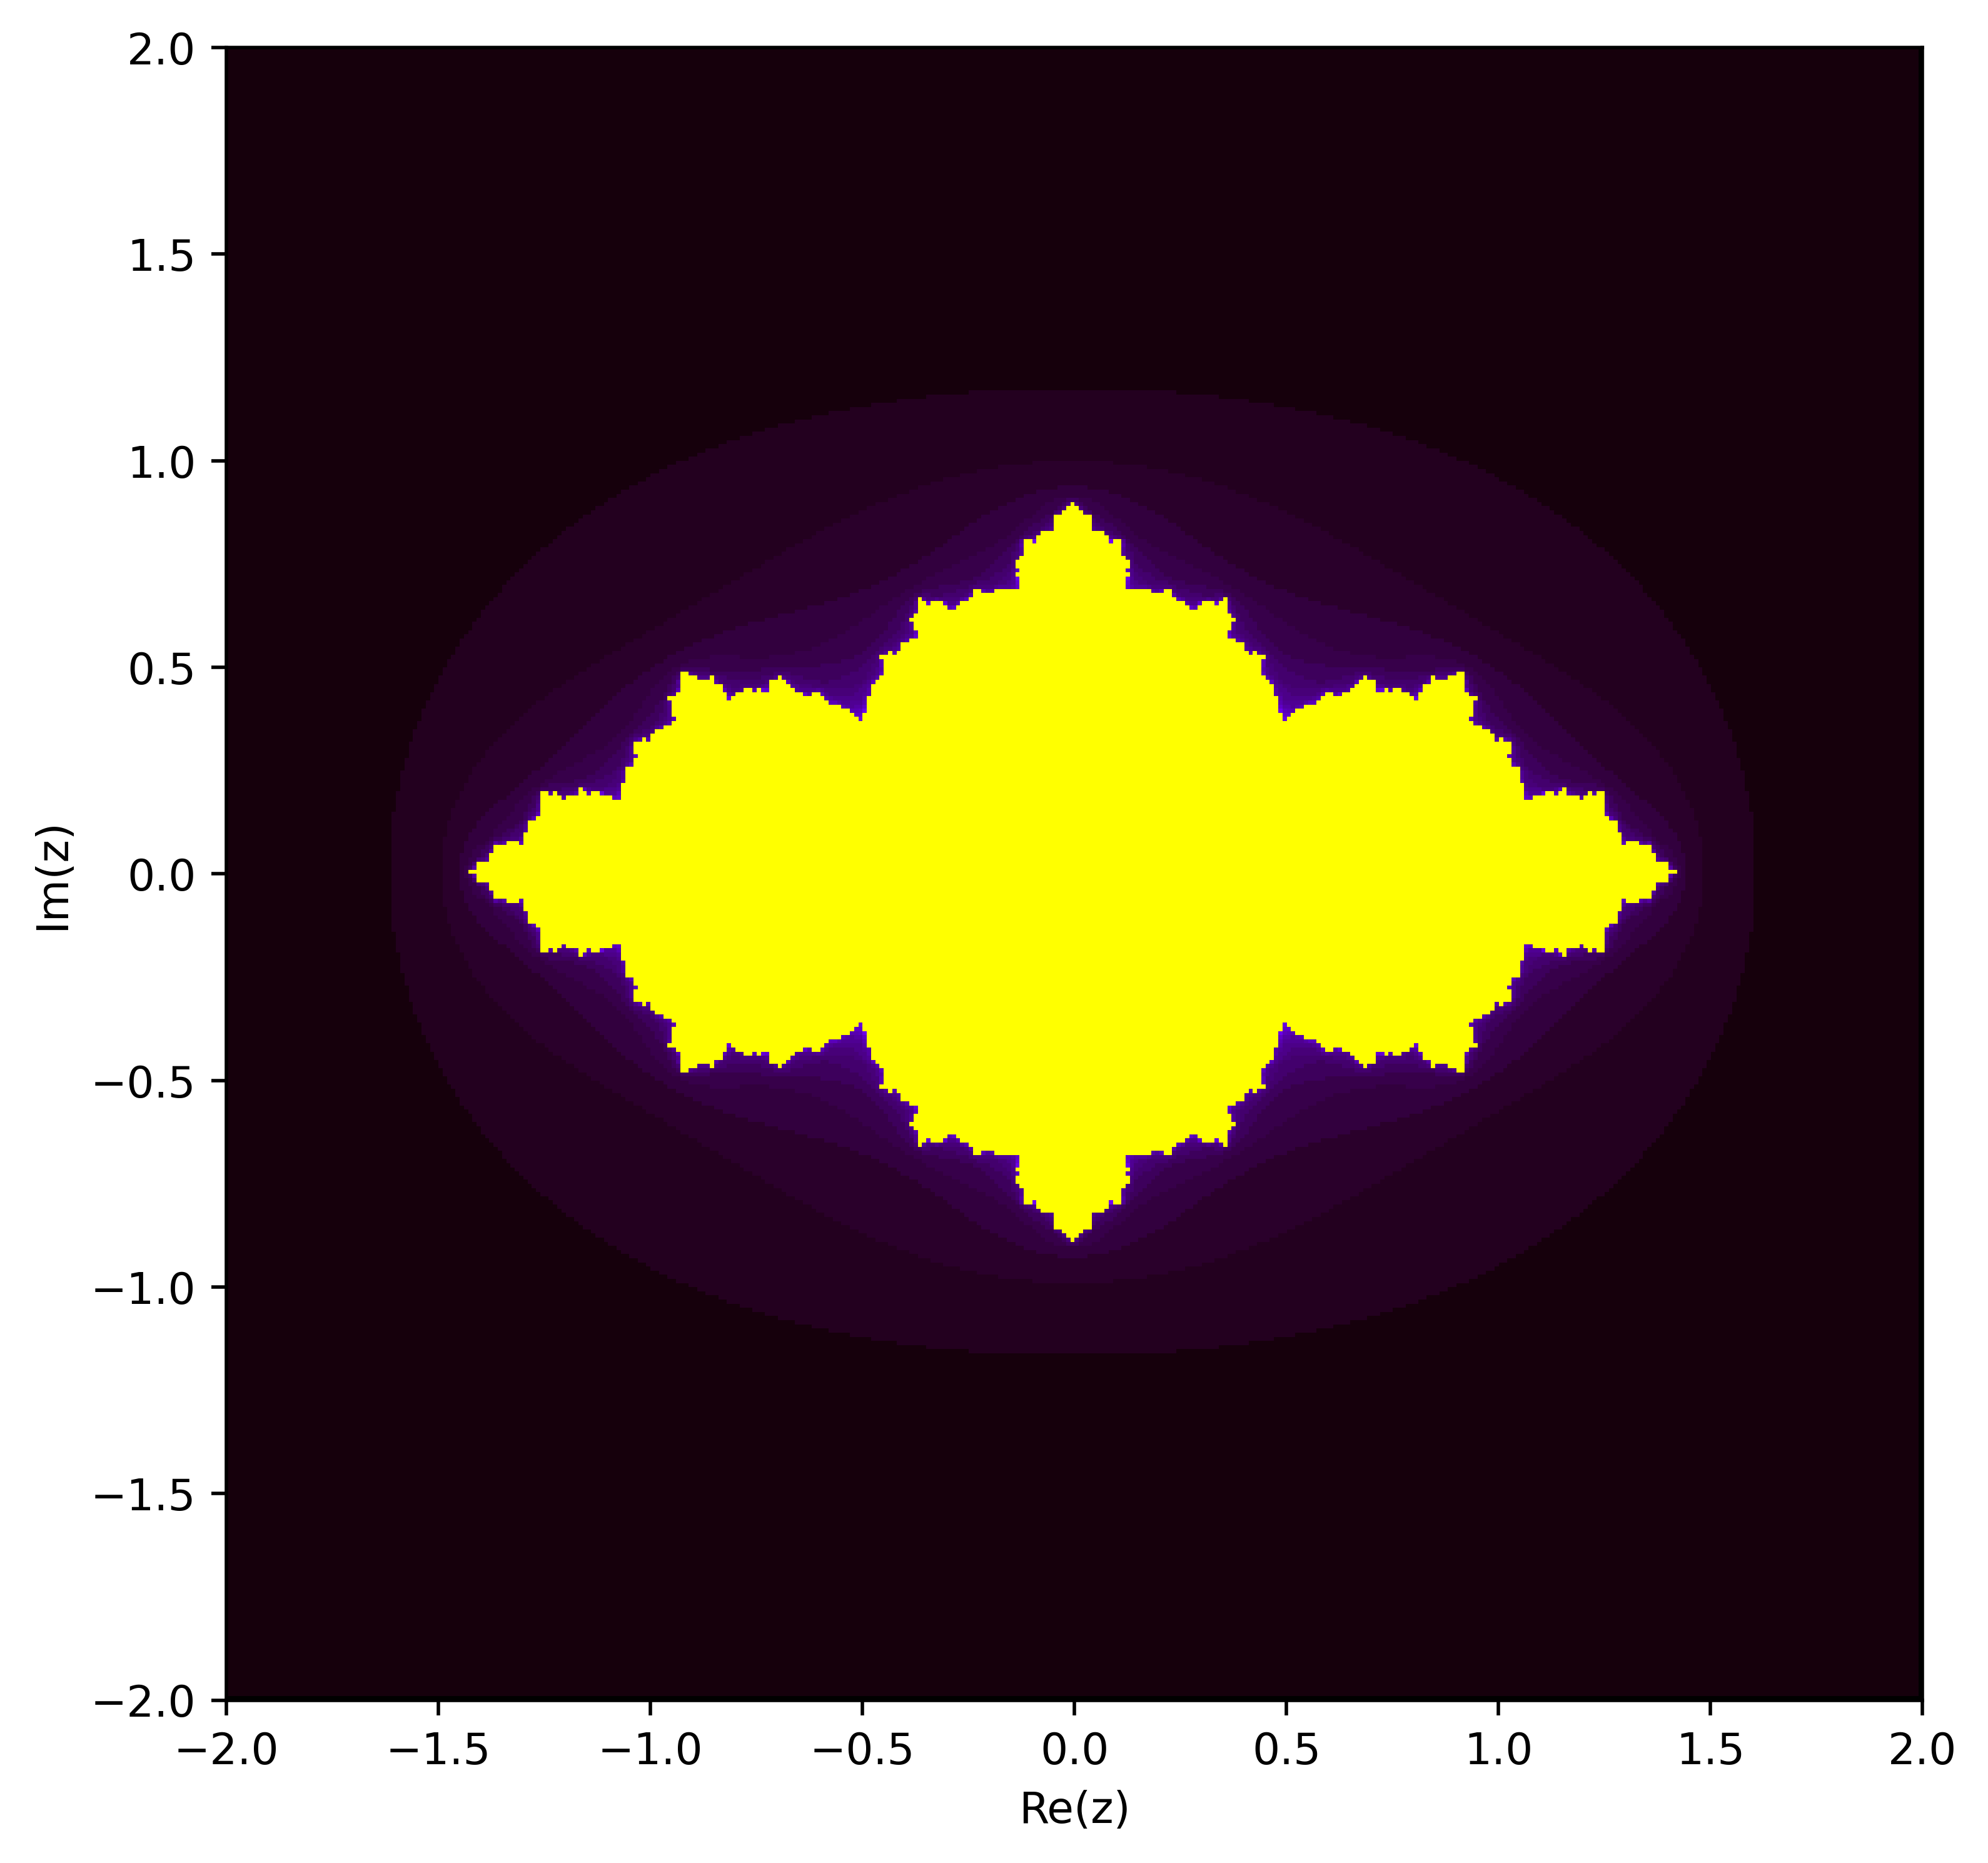

In [13]:
plt.figure(figsize = (7,7), dpi = 500)
plt.imshow(iters.transpose(), cmap='gnuplot', extent=[-2,2,-2, 2], aspect = 'auto')

plt.xlabel('Re(z)')
plt.ylabel('Im(z)')

Plot figures for c=exp(ia), a = range(0,2pi) & write down axes like in subtask 3, create animation of these figures slowly changing the a

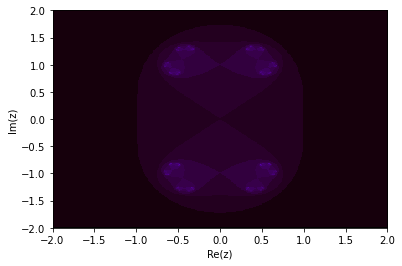

In [16]:
a = np.linspace(0,2*np.pi,100)
for i in a:
    c = np.exp(i*1.j)
    iters = julia_2(c)
#     plt.figure(figsize = (7,7), dpi = 500)
    plt.imshow(iters.transpose(), cmap='gnuplot', vmin = 0, vmax = 100, extent=[-2,2,-2, 2], aspect = 'auto', interpolation = 'nearest')
    plt.xlabel('Re(z)')
    plt.ylabel('Im(z)')
    plt.savefig('pictures/%f.png'%i, dpi = 400)

In [17]:
files = [f for f in listdir('pictures')]

image_path_list = files

image_list = [Image.open('pictures/' + file) for file in image_path_list]

image_list[0].save(
            'animation.gif',
    
            save_all=True,
            append_images=image_list[1:], # append rest of the images
            duration=100, # in milliseconds
            loop=0)